# The race car model under `pyomo-cvp`

This notebook shows exactly what `cvp.parameterize` does to the classic
minimum-time race car problem, next to the `reduce_collocation_points`
baseline: what the transformed model contains, how big it is, and that both
approaches solve to the same optimum (IPOPT).

In [1]:
import pyomo.environ as pyo
from pyomo.dae import ContinuousSet, DerivativeVar
from pyomo_cvp import declare_profile, control_value

L, R, NFE, NCP = 200.0, 0.001, 15, 3


def racecar():
    m = pyo.ConcreteModel()
    m.tau = ContinuousSet(bounds=(0, 1))
    m.x = pyo.Var(m.tau)
    m.v = pyo.Var(m.tau, bounds=(0, None))
    m.u = pyo.Var(m.tau, bounds=(-3, 1), initialize=0)
    m.tf = pyo.Var(bounds=(1, None), initialize=10)
    m.dx = DerivativeVar(m.x, wrt=m.tau)
    m.dv = DerivativeVar(m.v, wrt=m.tau)

    @m.Constraint(m.tau)
    def ode_x(m, t):
        if t == m.tau.first():
            return pyo.Constraint.Skip
        return m.dx[t] == m.tf * m.v[t]

    @m.Constraint(m.tau)
    def ode_v(m, t):
        if t == m.tau.first():
            return pyo.Constraint.Skip
        return m.dv[t] == m.tf * (m.u[t] - R * m.v[t] ** 2)

    m.ic_x = pyo.Constraint(expr=m.x[0] == 0)
    m.ic_v = pyo.Constraint(expr=m.v[0] == 0)
    m.fc_x = pyo.Constraint(expr=m.x[1] == L)
    m.fc_v = pyo.Constraint(expr=m.v[1] == 0)
    m.obj = pyo.Objective(expr=m.tf)
    return m


def sizes(m, tag):
    nv = sum(1 for v in m.component_data_objects(pyo.Var, active=True)
             if not v.fixed)
    nc = sum(1 for _ in m.component_data_objects(pyo.Constraint, active=True))
    nu = sum(1 for _ in m.u.values())
    print(f"{tag:42} vars={nv:4d}  cons={nc:4d}  u members={nu}")

## Baseline: `reduce_collocation_points`

The stock approach keeps every collocation-point copy of `u` and ties them
with equality constraints.

In [2]:
m_rcp = racecar()
d = pyo.TransformationFactory("dae.collocation")
d.apply_to(m_rcp, nfe=NFE, ncp=NCP, scheme="LAGRANGE-RADAU")
sizes(m_rcp, "after collocation")
d.reduce_collocation_points(m_rcp, var=m_rcp.u, ncp=1, contset=m_rcp.tau)
sizes(m_rcp, "after reduce_collocation_points (ncp=1)")
r = pyo.SolverFactory("ipopt").solve(m_rcp)
tf_rcp = pyo.value(m_rcp.tf)
print(f"IPOPT: {r.solver.termination_condition}, tf = {tf_rcp:.4f} s")

after collocation                          vars= 231  cons= 184  u members=46
after reduce_collocation_points (ncp=1)    vars= 231  cons= 214  u members=46


IPOPT: optimal, tf = 23.5747 s


## `pyomo-cvp`: same profile by elimination

Declare the profile at build time, discretize normally, then one
transformation call. `m.u` is replaced under its own name and afterwards has
exactly one member per finite element; there are no tie constraints and no
leftover copies.

In [3]:
m_cvp = racecar()
declare_profile(m_cvp.u, wrt=m_cvp.tau, profile="piecewise_constant")
pyo.TransformationFactory("dae.collocation").apply_to(
    m_cvp, nfe=NFE, ncp=NCP, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("cvp.parameterize").apply_to(m_cvp)
sizes(m_cvp, "after cvp.parameterize (piecewise constant)")
print("u members (element representative times):")
print([round(t, 4) for t in sorted(m_cvp.u)])
r = pyo.SolverFactory("ipopt").solve(m_cvp)
tf_cvp = pyo.value(m_cvp.tf)
print(f"IPOPT: {r.solver.termination_condition}, tf = {tf_cvp:.4f} s")
print(f"difference vs rcp baseline: {abs(tf_cvp - tf_rcp):.2e} s")

after cvp.parameterize (piecewise constant) vars= 200  cons= 184  u members=15
u members (element representative times):
[0.0667, 0.1333, 0.2, 0.2667, 0.3333, 0.4, 0.4667, 0.5333, 0.6, 0.6667, 0.7333, 0.8, 0.8667, 0.9333, 1]


IPOPT: optimal, tf = 23.5747 s
difference vs rcp baseline: 7.09e-08 s


## The optimal control profile

`control_value` evaluates the profile at any time; the optimal policy is the
expected bang-bang: full throttle, then full braking, within the declared
bounds $[-3, 1]$ everywhere.

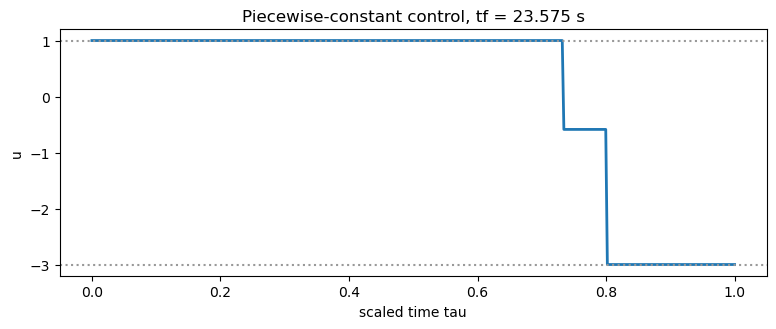

In [4]:
import matplotlib.pyplot as plt
import numpy as np

ts = np.linspace(0, 1, 400)
us = [control_value(m_cvp.u, float(t)) for t in ts]
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(ts, us, lw=2)
ax.axhline(1, color="0.6", ls=":"); ax.axhline(-3, color="0.6", ls=":")
ax.set_xlabel("scaled time tau"); ax.set_ylabel("u")
ax.set_title(f"Piecewise-constant control, tf = {tf_cvp:.3f} s")
plt.tight_layout(); plt.show()

## Reduced collocation ($k=2$), including the bound rows

With $k>1$ free values per element, eliminated points are Lagrange
combinations whose coefficients can leave $[0,1]$, so the original variable
bounds are not implied by the knot bounds. The transformation therefore adds
explicit bound rows (`u_profile_bounds`) at those points, matching
`reduce_collocation_points`' semantics of bounds at every collocation point.
Both models solve to the same optimum from a cold start.

In [5]:
m1 = racecar()
d = pyo.TransformationFactory("dae.collocation")
d.apply_to(m1, nfe=NFE, ncp=NCP, scheme="LAGRANGE-RADAU")
d.reduce_collocation_points(m1, var=m1.u, ncp=2, contset=m1.tau)
pyo.SolverFactory("ipopt").solve(m1)
sizes(m1, "rcp (ncp=2)")

m2 = racecar()
pyo.TransformationFactory("dae.collocation").apply_to(
    m2, nfe=NFE, ncp=NCP, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("cvp.parameterize").apply_to(
    m2, var=m2.u, contset=m2.tau, profile=("reduced_collocation", 2))
pyo.SolverFactory("ipopt").solve(m2)
sizes(m2, "cvp reduced_collocation k=2")
nb = len(list(m2.u_profile_bounds.values()))
print(f"explicit bound rows added: {nb}")
print(f"tf: rcp = {pyo.value(m1.tf):.4f}, cvp = {pyo.value(m2.tf):.4f}")
worst = min(control_value(m2.u, float(t)) for t in sorted(m2.tau))
print(f"minimum of the cvp control over all collocation points: {worst:.3f} "
      f"(bound -3)")

rcp (ncp=2)                                vars= 231  cons= 199  u members=46


cvp reduced_collocation k=2                vars= 215  cons= 200  u members=30
explicit bound rows added: 16
tf: rcp = 23.5175, cvp = 23.5175
minimum of the cvp control over all collocation points: -3.000 (bound -3)


## Piecewise-linear (continuous) profile

`'piecewise_linear'` keeps one free value per element boundary (nfe + 1
members), continuous across elements; interior points are convex
combinations of the two surrounding knots, so the knot bounds imply the
bounds everywhere and no extra rows are needed. The final plot overlays
all three profiles.

after cvp.parameterize (piecewise linear)  vars= 201  cons= 184  u members=16


IPOPT: optimal, tf = 23.5563 s


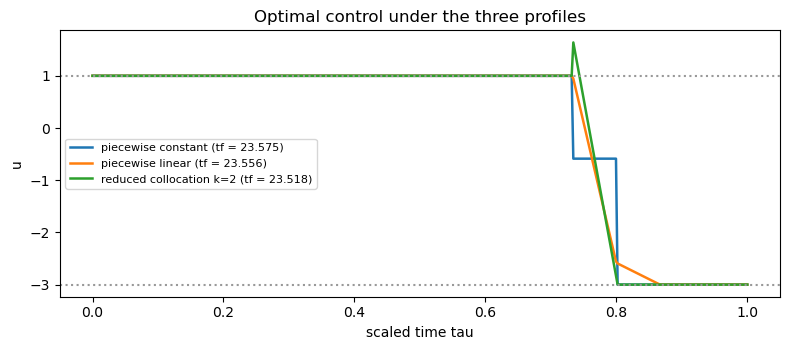

In [6]:
m_pwl = racecar()
pyo.TransformationFactory("dae.collocation").apply_to(
    m_pwl, nfe=NFE, ncp=NCP, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("cvp.parameterize").apply_to(
    m_pwl, var=m_pwl.u, contset=m_pwl.tau, profile="piecewise_linear")
sizes(m_pwl, "after cvp.parameterize (piecewise linear)")
r = pyo.SolverFactory("ipopt").solve(m_pwl)
tf_pwl = pyo.value(m_pwl.tf)
print(f"IPOPT: {r.solver.termination_condition}, tf = {tf_pwl:.4f} s")

fig, ax = plt.subplots(figsize=(8, 3.6))
for var, tf, label in [(m_cvp.u, tf_cvp, "piecewise constant"),
                       (m_pwl.u, tf_pwl, "piecewise linear"),
                       (m2.u, pyo.value(m2.tf), "reduced collocation k=2")]:
    ax.plot(ts, [control_value(var, float(t)) for t in ts], lw=1.8,
            label=f"{label} (tf = {tf:.3f})")
ax.axhline(1, color="0.6", ls=":"); ax.axhline(-3, color="0.6", ls=":")
ax.set_xlabel("scaled time tau"); ax.set_ylabel("u")
ax.set_title("Optimal control under the three profiles")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()